## RUL Modeling and Model Comparison

#### This notebook focuses on predicting Remaining Useful Life (RUL) using machine learning regression models.

#### The models will be trained using the engineered features created during sensor degradation analysis and evaluated on unseen validation engines.

#### The goal is to compare different regression models using MAE, MSE, RMSE, and R².

In [1]:
import pandas as pd

columns = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    "CMAPSSData/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# Create RUL
train["RUL"] = (
    train.groupby("engine_id")["cycle"]
    .transform("max") - train["cycle"]
)

train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [2]:
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train_clean = train.drop(columns=constant_sensors)

train_clean.shape

(20631, 21)

In [3]:
# Create the engineered features
feature_sensors = [
    col for col in train_clean.columns
    if col.startswith("sensor_")
]

feature_data = train_clean.copy()

for sensor in feature_sensors:

    feature_data[f"{sensor}_rolling_mean"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
    )

    feature_data[f"{sensor}_rolling_std"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).std()
        )
    )

    feature_data[f"{sensor}_delta"] = (
        feature_data.groupby("engine_id")[sensor].diff()
    )

In [4]:
feature_data = feature_data.fillna(0)

In [5]:
# Make the same engine-level split
from sklearn.model_selection import train_test_split

engine_ids = feature_data["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = feature_data[
    feature_data["engine_id"].isin(train_engines)
].copy()

val_data = feature_data[
    feature_data["engine_id"].isin(val_engines)
].copy()

In [6]:
# Seperate X and y
X_train = train_data.drop(columns=["RUL", "engine_id"])
y_train = train_data["RUL"]

X_val = val_data.drop(columns=["RUL", "engine_id"])
y_val = val_data["RUL"]

In [7]:
print(X_train.shape)
print(X_val.shape)

(16561, 64)
(4070, 64)


In [8]:
# Verify the split
print("Training engines:", train_data["engine_id"].nunique())
print("Validation engines:", val_data["engine_id"].nunique())

print("Training shape:", train_data.shape)
print("Validation shape:", val_data.shape)

Training engines: 80
Validation engines: 20
Training shape: (16561, 66)
Validation shape: (4070, 66)


In [9]:
# Create X and y
X_train = train_data.drop(columns=["RUL", "engine_id"])
y_train = train_data["RUL"]

X_val = val_data.drop(columns=["RUL", "engine_id"])
y_val = val_data["RUL"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (16561, 64)
X_val: (4070, 64)


In [10]:
# Now do StandardScaller before training our second RUL model for comparison with Random Forest Regressor
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
# fit-->learn mean and standard deviation from X_train
# transform--> use those values to scale X_train
X_train_scaled = scaler.fit_transform(X_train)

In [13]:
X_val_scaled = scaler.transform(X_val)

In [14]:
print("Original shape:", X_train.shape)
print("Scaled shape:", X_train_scaled.shape)

print("Training mean:", X_train_scaled.mean())
print("Training std:", X_train_scaled.std())

Original shape: (16561, 64)
Scaled shape: (16561, 64)
Training mean: -3.1055793960514144e-14
Training std: 0.9921567416492215


In [16]:
# Train SVR
from sklearn.svm import LinearSVR
svr_model = LinearSVR(
    C=0.1,
    max_iter=20000,
    random_state=42
)

In [17]:
svr_model.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",20000
,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",0.0
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"loss loss: {'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='epsilon_insensitive'Specifies the loss function. The epsilon-insensitive loss(standard SVR) is the L1 loss, while the squared epsilon-insensitiveloss ('squared_epsilon_insensitive') is the L2 loss.",'epsilon_insensitive'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes `[x_1, ...,x_n, intercept_scaling]`, i.e. a ""synthetic"" feature with a constantvalue equal to `intercept_scaling` is appended to the instance vector.The intercept becomes intercept_scaling * synthetic feature weight.Note that liblinear internally penalizes the intercept, treating itlike any other term in the feature vector. To reduce the impact of theregularization on the intercept, the `intercept_scaling` parameter canbe set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1.0
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features` and `loss`. If`n_samples` < `n_features` and optimizer supports chosen `loss`,then dual will be set to True, otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
Name,Type,Value


In [18]:
y_pred_svr = svr_model.predict(X_val_scaled)

print("Actual RUL:   ", y_val.values[:10])
print("SVR Predicted:", y_pred_svr[:10])

Actual RUL:    [191 190 189 188 187 186 185 184 183 182]
SVR Predicted: [183.63779544 165.6500536  163.54978442 168.40635987 163.02953901
 163.52773277 164.77775545 160.47940494 160.58312618 163.53985788]


In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [21]:
mae_svr = mean_absolute_error(y_val, y_pred_svr)
mse_svr = mean_squared_error(y_val, y_pred_svr)
rmse_svr = mse_svr ** 0.5
r2_svr = r2_score(y_val, y_pred_svr)

print("SVR MAE :", mae_svr)
print("SVR MSE :", mse_svr)
print("SVR RMSE:", rmse_svr)
print("SVR R²  :", r2_svr)

SVR MAE : 25.019292750078602
SVR MSE : 1079.1918960443675
SVR RMSE: 32.85105623940222
SVR R²  : 0.7496174827426084


In [23]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 5.1 MB/s eta 0:00:10
   - -------------------------------------- 1.8/48.9 MB 4.4 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/48.9 MB 4.3 MB/s eta 0:00:11
   -- ------------------------------------- 2.9/48.9 MB 4.2 MB/s eta 0:00:11
   -- ------------------------------------- 2.9/48.9 MB 4.2 MB/s eta 0:00:11
   -- ------------------------------------- 3.1/48.9 MB 2.5 MB/s eta 0:00:19
   --- ------------------------------------ 4.2/48.9 MB 2.7 MB/s eta 0:00:17
   ---- ----------------------------------- 5.0/48.9 MB 2.9 MB/s eta 0:00:16
   ---- ----------------------------------- 5.5/48.9 MB 2.8 MB/s eta 0:00:16
   ----- ---------------------------------- 6.6/48.9 MB 3.1 MB/s eta 0:00:14
   ----- ---------------------------------- 7.3/48.9 MB 3.1 MB/s eta 0:00:14
   ------ --------------------------------- 8.1/48.9 MB 3.2 MB/s eta 0:00:13
   ---

In [24]:
# Import XGBoost
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [25]:
# Creating the XGBoost model
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [26]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [27]:
y_pred_xgb = xgb_model.predict(X_val)

print("Actual RUL:    ", y_val.values[:10])
print("XGBoost Predicted:", y_pred_xgb[:10])

Actual RUL:     [191 190 189 188 187 186 185 184 183 182]
XGBoost Predicted: [231.96127 260.38913 218.76811 214.5418  209.98378 211.28317 239.59682
 220.14023 191.50212 163.56299]


In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_pred_xgb)
rmse_xgb = mse_xgb ** 0.5
r2_xgb = r2_score(y_val, y_pred_xgb)

print("XGBoost MAE :", mae_xgb)
print("XGBoost MSE :", mse_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²  :", r2_xgb)

XGBoost MAE : 23.578367233276367
XGBoost MSE : 999.5707397460938
XGBoost RMSE: 31.615988672601933
XGBoost R²  : 0.7680903673171997


In [30]:
# Comparison all three models
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SVR", "XGBoost"],
    "MAE": [23.528966830466832, 25.019292750078602, mae_xgb],
    "MSE": [1016.929355958232, 1079.1918960443675, mse_xgb],
    "RMSE": [31.889197788527436, 32.85105623940222, rmse_xgb],
    "R2": [0.7640649224299252, 0.7496174827426084, r2_xgb]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Random Forest,23.528967,1016.929356,31.889198,0.764065
1,SVR,25.019293,1079.191896,32.851056,0.749617
2,XGBoost,23.578367,999.570740,31.615989,0.768090


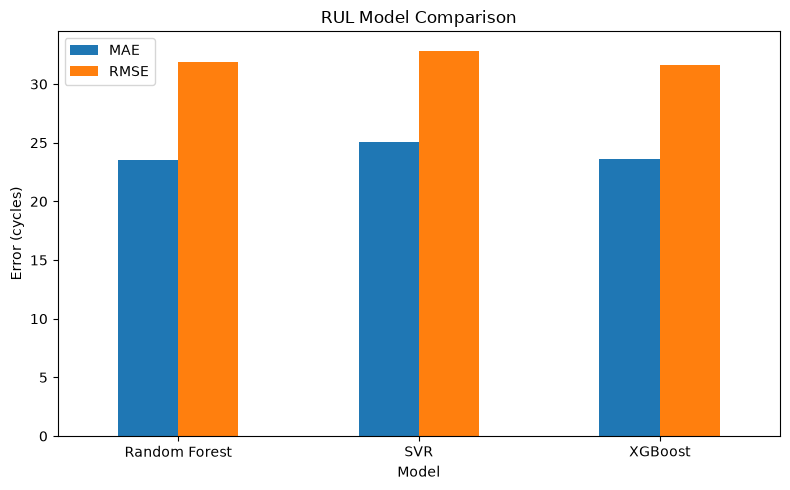

In [31]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Error (cycles)")
plt.title("RUL Model Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()